In [1]:
import torch
from torch import nn, optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import time
import pandas as pd
import os
from glob import glob
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

/home/mahirwar/miniconda3/envs/kfold_amy_plaque1/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/home/mahirwar/miniconda3/envs/kfold_amy_plaque1/lib/python3.9/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [3]:
df1= pd.read_csv("/gladstone/finkbeiner/steve/work/data/npsad_data/monika/LBD/crop_classifier/preds.csv")

In [5]:
df1["match"] = df1["preds"]==df1["label"]
df1["match"] = df1["match"].astype(int)

In [6]:
matched = df1.groupby(["image_name"])["match"].sum()/df1.groupby(["image_name"])["path"].count()

In [7]:
matched[matched<0.99]

image_name
DLB-PD189-C34-45-Amygdala_files               0.988284
PD097-C34-45-Striatum_files                   0.953309
PD102-C34-45-Striatum_files                   0.921596
PD118-C34-45-Striatum_files                   0.957971
PD130-C34-45-Striatum_files                   0.944075
PD131-C34-45-Striatum_files                   0.974937
PD134-DLB-Striatum-C34-45_files               0.930769
PD152-DLB-EntCx-AnteriorHippo-C34-45_files    0.987489
PD152-DLB-Striatum-C34-45_files               0.989679
PD158-C34-45-Striatum_files                   0.962505
PD159-C34-45-Striatum_files                   0.985723
PD189-DLB-C34-45-EntCx-Hippo_files            0.942116
PD226-DLB--EntCx-C110-115_files               0.955905
PD226-DLB-Amygdala-C34-45_files               0.977154
PD226-DLB-EntCx-C34-45_files                  0.981528
PD226-DLB-Striatum-C34-45_files               0.981580
PD60-DLB-Amygdala-C34-45-001_files            0.953769
PD60-DLB-Amygdala-C34-45-002_files            0.966018

In [8]:
df1["antibody"] = df1["image_name"].apply(lambda l: "C34-45" if l.find("34-45")!=-1 else "C110-115")

In [9]:
def assign_brain_region(l):
    if l.find("Striatum")!=-1:
        return "Striatum"
    if l.find("Amyg")!=-1:
        return "Amygdala"
    if l.find("Ent")!=-1:
        return "EntCx"
    return None

In [10]:
df1["brain_region"] = df1["image_name"].apply(lambda l: assign_brain_region(l))

In [11]:
df1.groupby(["antibody"])["match"].sum()/df1.groupby(["antibody"])["path"].count()

antibody
C110-115    0.997421
C34-45      0.988607
dtype: float64

In [13]:
df1.groupby(["brain_region"])["match"].sum()/df1.groupby(["brain_region"])["path"].count()

brain_region
Amygdala    0.996378
EntCx       0.995019
Striatum    0.983009
dtype: float64

In [20]:
df1["slide_id"] = df1["image_name"].apply(lambda l: l.replace("_files",".svs"))

In [16]:
data_all = pd.read_csv("/gladstone/finkbeiner/steve/work/data/npsad_data/monika/Antibodies_detection/codes/prov-gigapath/data/antibodies_data/data_imperial3.csv")

In [18]:
data_all

,slide_id,brain_region,pat_id,anitibody,LBD_flag,label,Brain_bank
0,PD134-DLB--Amygdala-C110-115.svs,Amygdala,PD134,C110-115,DLB,1,Oxford
1,PD134-DLB--EntCx-C110-115.svs,EntCx,PD134,C110-115,DLB,1,Oxford
2,PD134-DLB--EntCx-C34-45.svs,EntCx,PD134,C34-45,DLB,1,Oxford
3,PD134-DLB-Striatum-C34-45.svs,Striatum,PD134,C34-45,DLB,1,Oxford
4,PD152-DLB--Striatum-C110-115.svs,Striatum,PD152,C110-115,DLB,1,Oxford
...,...,...,...,...,...,...,...
73,PD17_C34-45_EntCx.svs,EntCx,PD17,C34-45,PDD,0,Oxford
74,PD17_C34-45_Amygdala.svs,Amygdala,PD17,C34-45,PDD,0,Oxford
75,PD17_EntCx_C110-115.svs,EntCx,PD17,C110-115,PDD,0,Oxford
76,PD17-C34-45-Striatum.svs,Striatum,PD17,C34-45,PDD,0,Oxford


In [22]:
df1 = pd.merge(df1, data_all[["slide_id","pat_id"]], on ="slide_id", how = "left")

In [26]:
df1["mismatch"] = 1 - df1["match"]

In [155]:
df1["mismatch"].value_counts()

mismatch
0    428255
1      2871
Name: count, dtype: int64

# Analysis for Antibodies

In [30]:
aggregated_pat = df1.groupby(["pat_id","brain_region","antibody"]).agg({"mismatch":["sum"], "match":["sum","count"]}).reset_index()

In [34]:
aggregated_pat[:29]

pat_id brain_region  antibody mismatch match      
                                      sum   sum count
0   PD102     Amygdala  C110-115        0  4840  4840
1   PD102     Amygdala    C34-45        0  4766  4766
2   PD102        EntCx  C110-115        0  3929  3929
3   PD102        EntCx    C34-45        0  3703  3703
4   PD102     Striatum  C110-115        3  2647  2650
5   PD102     Striatum    C34-45      224  2633  2857
6   PD131     Amygdala  C110-115        0  4301  4301
7   PD131     Amygdala    C34-45        0  4237  4237
8   PD131        EntCx  C110-115        0  3725  3725
9   PD131     Striatum  C110-115        0  2910  2910
10  PD131     Striatum    C34-45       80  3112  3192
11  PD133     Amygdala  C110-115        0  2953  2953
12  PD133     Amygdala    C34-45        0  2969  2969
13  PD133        EntCx    C34-45        1  6296  6297
14  PD133     Striatum  C110-115        0  1524  1524
15  PD133     Striatum    C34-45        4  1897  1901
16  PD134     Amygdala  C110-115       24  3279  3303
17  PD134        EntCx  C110-115        9  3024  3033
18  PD134        EntCx    C34-45       27  3474  3501
19  PD134     Striatum    C34-45      108  1452  1560
20  PD151     Amygdala  C110-115       42  4690  4732
21  PD151     Amygdala    C34-45        4  4972  4976
22  PD151        EntCx  C110-115        0  5211  5211
23  PD151        EntCx    C34-45        1  5412  5413
24  PD151     Striatum  C110-115        0  2651  2651
25  PD152     Amygdala    C34-45        7  3810  3817
26  PD152        EntCx    C34-45       71  5604  5675
27  PD152     Striatum  C110-115        3  2512  2515
28  PD152     Striatum    C34-45       27  2589  2616

In [35]:
aggregated_pat[29:]

pat_id brain_region  antibody mismatch match       
                                      sum   sum  count
29  PD158     Amygdala  C110-115        0  8276   8276
30  PD158        EntCx  C110-115        0  4842   4842
31  PD158        EntCx    C34-45        1  4927   4928
32  PD158     Striatum  C110-115        0  2186   2186
33  PD158     Striatum    C34-45       94  2413   2507
34  PD159     Amygdala  C110-115        1  6740   6741
35  PD159     Amygdala    C34-45        0  6210   6210
36  PD159        EntCx  C110-115        0  6329   6329
37  PD159     Striatum  C110-115        0  3481   3481
38  PD159     Striatum    C34-45       49  3383   3432
39  PD163     Amygdala    C34-45       23  6534   6557
40  PD163        EntCx  C110-115       24  2657   2681
41  PD163        EntCx    C34-45        6  3003   3009
42   PD17     Amygdala  C110-115        0  4195   4195
43   PD17     Amygdala    C34-45        9  4252   4261
44   PD17        EntCx  C110-115        9  4057   4066
45   PD17        EntCx    C34-45        0  3427   3427
46   PD17     Striatum  C110-115        4  1290   1294
47   PD17     Striatum    C34-45        1  1229   1230
48  PD189     Amygdala  C110-115        0  4935   4935
49  PD189     Amygdala    C34-45       59  4977   5036
50  PD189        EntCx  C110-115       30  4128   4158
51  PD189        EntCx    C34-45      289  8478   8767
52  PD189     Striatum    C34-45       30  4973   5003
53  PD195     Amygdala  C110-115        1  3143   3144
54  PD195     Amygdala    C34-45        7  3246   3253
55  PD195        EntCx  C110-115        2  3564   3566
56  PD195        EntCx    C34-45        2  4267   4269
57  PD226     Amygdala  C110-115       22  5900   5922
58  PD226     Amygdala    C34-45      136  5817   5953
59  PD226        EntCx  C110-115      202  4379   4581
60  PD226        EntCx    C34-45       89  4729   4818
61  PD226     Striatum    C34-45       83  4423   4506
62   PD60     Amygdala    C34-45      301  9836  10137
63   PD60        EntCx  C110-115       10  2728   2738
64   PD60     Striatum  C110-115        3  2473   2476
65   PD89     Amygdala    C34-45       33  4580   4613
66   PD89        EntCx  C110-115       12  4471   4483
67   PD89     Striatum  C110-115        3  1987   1990
68   PD89     Striatum    C34-45       41  2172   2213
69   PD97     Amygdala  C110-115        0  4841   4841
70   PD97     Amygdala    C34-45        0  4875   4875
71   PD97        EntCx  C110-115        0  5925   5925
72   PD97        EntCx    C34-45        2  5470   5472
73   PD97     Striatum  C110-115        5  2143   2148
74   PD97     Striatum    C34-45      103  2103   2206

In [37]:
aggregated_pat.columns =  ["pat_id","brain_region","antibody","mismatched_count","matched_crops","total_crops"]

In [94]:
aggregated_pat.to_csv("/gladstone/finkbeiner/steve/work/data/npsad_data/monika/LBD/crop_classifier/pat_wise_misclass_antibody.csv")

In [56]:
aggregated_pat1 = aggregated_pat.groupby(["pat_id","brain_region"])["mismatched_count"].count().reset_index()

In [62]:
agg_gr2 = aggregated_pat1[aggregated_pat1["mismatched_count"]>1]

In [61]:
len(aggregated_pat1[aggregated_pat1["mismatched_count"]>1])

29

In [64]:
aggregated_pat = pd.merge(aggregated_pat,agg_gr2,on=["pat_id","brain_region"], how="left")

In [69]:
pairs = aggregated_pat[aggregated_pat["mismatched_count_y"]==2]

In [73]:
pivoted_pairs  = pairs.pivot(index = ["pat_id","brain_region"], columns = ["antibody"], values = ["mismatched_count_x"]).reset_index()

In [75]:
pivoted_pairs.columns = ["pat_id","brain_region","C110-115_mismatched_crop_count","C34-45_mismatched_crop_count"]

In [77]:
pivoted_pairs["count_diff"] = pivoted_pairs["C110-115_mismatched_crop_count"] - pivoted_pairs["C34-45_mismatched_crop_count"]


In [80]:
pivoted_pairs["count_diff"].describe()

count     29.000000
mean     -30.862069
std       72.979804
min     -259.000000
25%      -49.000000
50%       -2.000000
75%        0.000000
max      113.000000
Name: count_diff, dtype: float64

In [92]:
pivoted_pairs[pivoted_pairs["count_diff"]<-10]

,pat_id,brain_region,C110-115_mismatched_crop_count,C34-45_mismatched_crop_count,count_diff
2,PD102,Striatum,3,224,-221
4,PD131,Striatum,0,80,-80
7,PD134,EntCx,9,27,-18
10,PD152,Striatum,3,27,-24
12,PD158,Striatum,0,94,-94
14,PD159,Striatum,0,49,-49
19,PD189,Amygdala,0,59,-59
20,PD189,EntCx,30,289,-259
23,PD226,Amygdala,22,136,-114
25,PD89,Striatum,3,41,-38


In [93]:
pivoted_pairs[pivoted_pairs["count_diff"]>10]

,pat_id,brain_region,C110-115_mismatched_crop_count,C34-45_mismatched_crop_count,count_diff
8,PD151,Amygdala,42,4,38
15,PD163,EntCx,24,6,18
24,PD226,EntCx,202,89,113


In [95]:
pivoted_pairs.to_csv("/gladstone/finkbeiner/steve/work/data/npsad_data/monika/LBD/crop_classifier/pairwise_misclass_antibody.csv")

# Analysis for Brain Region

In [96]:
aggregated_pat = df1.groupby(["pat_id","antibody","brain_region"]).agg({"mismatch":["sum"], "match":["sum","count"]}).reset_index()

In [99]:
aggregated_pat.columns  =  ["pat_id","antibody","brain_region", "mismatched_crops","matched_crops","total_crops"]

In [145]:
pivot_br = aggregated_pat.pivot(index = ["pat_id","antibody"], columns = ["brain_region"], values = ["mismatched_crops"]).reset_index()

In [146]:
pivot_br.columns =  ["pat_id","antibody", "mismatched_crops_Amygdala","mismatched_crops_EntCx","mismatched_crops_Striatum"]

In [147]:
pivot_br.to_csv("/gladstone/finkbeiner/steve/work/data/npsad_data/monika/LBD/crop_classifier/all_pairs_mismatched_brain_region.csv")

In [142]:
def get_max_count_region(l):
    if (l["mismatched_crops_Amygdala"]==l["mismatched_crops_EntCx"]) and (l["mismatched_crops_Striatum"]==l["mismatched_crops_EntCx"]):
        return None
    max_count_id = np.nanargmax([l["mismatched_crops_Amygdala"],l["mismatched_crops_EntCx"],l["mismatched_crops_Striatum"]])
    if max_count_id==0:
        return "Amygdala"
    if max_count_id==1:
        return "EntCx"
    if max_count_id==2:
        return "Striatum"
    return None

In [143]:
pivot_br["max_count_region"] = pivot_br.apply(lambda l: get_max_count_region(l), axis=1)


In [144]:
pivot_br

,pat_id,antibody,mismatched_crops_Amygdala,mismatched_crops_EntCx,mismatched_crops_Striatum,max_count_region
0,PD102,C110-115,0.0,0.0,3.0,Striatum
1,PD102,C34-45,0.0,0.0,224.0,Striatum
2,PD131,C110-115,0.0,0.0,0.0,None
3,PD131,C34-45,0.0,NaN,80.0,Striatum
4,PD133,C110-115,0.0,NaN,0.0,Amygdala
5,PD133,C34-45,0.0,1.0,4.0,Striatum
6,PD134,C110-115,24.0,9.0,NaN,Amygdala
7,PD134,C34-45,NaN,27.0,108.0,Striatum
8,PD151,C110-115,42.0,0.0,0.0,Amygdala
9,PD151,C34-45,4.0,1.0,NaN,Amygdala


In [123]:
dropped_na  = pivot_br.dropna()

In [124]:
dropped_na["max_count_region"] = dropped_na.apply(lambda l: get_max_count_region(l), axis=1)


/tmp/ipykernel_1133945/1989389748.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dropped_na["max_count_region"] = dropped_na.apply(lambda l: get_max_count_region(l), axis=1)


In [126]:
dropped_na["max_count_region"].value_counts()

max_count_region
Striatum    5
Amygdala    4
EntCx       3
Name: count, dtype: int64

In [148]:
pivot_br = pivot_br.fillna(0)
pivot_br["max_count_region"] = pivot_br.apply(lambda l: get_max_count_region(l), axis=1)


In [149]:
pivot_br["max_count_region"].value_counts()

max_count_region
Striatum    11
Amygdala     9
EntCx        9
Name: count, dtype: int64

In [150]:
len(pivot_br)

32

In [151]:
pivot_br["max_mismatched_val"] = pivot_br.apply(lambda l: max(l["mismatched_crops_Amygdala"],l["mismatched_crops_EntCx"],l["mismatched_crops_Striatum"]), axis=1)

In [152]:
pivot_br[pivot_br["max_mismatched_val"]>10]["max_count_region"].value_counts()

max_count_region
Striatum    7
EntCx       6
Amygdala    5
Name: count, dtype: int64

In [153]:
pivot_br.to_csv("/gladstone/finkbeiner/steve/work/data/npsad_data/monika/LBD/crop_classifier/all_pairs_mismatched_brain_region_final.csv")

# Visualize Images with mismatch

In [156]:
aggregated_pat = pd.read_csv("/gladstone/finkbeiner/steve/work/data/npsad_data/monika/LBD/crop_classifier/pat_wise_misclass_antibody.csv")

In [157]:
aggregated_pat

,Unnamed: 0,pat_id,brain_region,antibody,mismatched_count_x,matched_crops,total_crops,mismatched_count_y
0,0,PD102,Amygdala,C110-115,0,4840,4840,2.0
1,1,PD102,Amygdala,C34-45,0,4766,4766,2.0
2,2,PD102,EntCx,C110-115,0,3929,3929,2.0
3,3,PD102,EntCx,C34-45,0,3703,3703,2.0
4,4,PD102,Striatum,C110-115,3,2647,2650,2.0
...,...,...,...,...,...,...,...,...
70,70,PD97,Amygdala,C34-45,0,4875,4875,2.0
71,71,PD97,EntCx,C110-115,0,5925,5925,2.0
72,72,PD97,EntCx,C34-45,2,5470,5472,2.0
73,73,PD97,Striatum,C110-115,5,2143,2148,2.0


In [158]:
pairwise = pd.read_csv("/gladstone/finkbeiner/steve/work/data/npsad_data/monika/LBD/crop_classifier/pairwise_misclass_antibody.csv")

In [161]:
pairwise[pairwise["count_diff"]<-50]

,Unnamed: 0,pat_id,brain_region,C110-115_mismatched_crop_count,C34-45_mismatched_crop_count,count_diff
2,2,PD102,Striatum,3,224,-221
4,4,PD131,Striatum,0,80,-80
12,12,PD158,Striatum,0,94,-94
19,19,PD189,Amygdala,0,59,-59
20,20,PD189,EntCx,30,289,-259
23,23,PD226,Amygdala,22,136,-114
28,28,PD97,Striatum,5,103,-98


In [180]:
paths = df1[(df1["pat_id"]== "PD102") & (df1["antibody"] == "C34-45") & (df1["mismatch"]==1)]["path"].values

In [193]:
img = Image.open(paths[80]).convert("RGB")
img_resized = img.resize((512, 512))
img_np = np.array(img_resized) / 255.0  # [H, W, 3], float32 in range [0, 1]

(-0.5, 511.5, 511.5, -0.5)

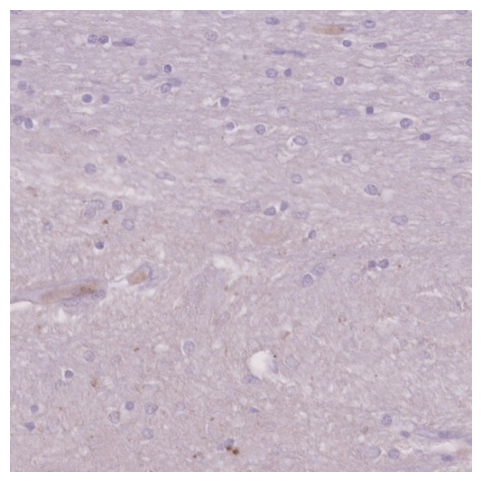

In [194]:
plt.figure(figsize=(6, 6))
plt.imshow(img_resized)
plt.axis("off")

In [2]:
data_all = pd.read_csv("/gladstone/finkbeiner/steve/work/data/npsad_data/monika/Antibodies_detection/codes/prov-gigapath/data/antibodies_data/data_imperial3.csv")

In [3]:
data_all.head(1)

,slide_id,brain_region,pat_id,anitibody,LBD_flag,label,Brain_bank
0,PD134-DLB--Amygdala-C110-115.svs,Amygdala,PD134,C110-115,DLB,1,Oxford


In [4]:
all_preds = pd.read_excel("/gladstone/finkbeiner/steve/work/data/npsad_data/monika/Antibodies_detection/codes/tmi2022/antibodies_data/all_preds_kfold.xlsx")

In [5]:
len(all_preds)

78

In [6]:
all_preds

,kfold 0,input,act_labels,pred_labels
0,0,PD152-DLB-Striatum-C34-45,1,1
1,0,PD189-DLB--EntCx-C110-115,1,1
2,0,PD195-DLB--Amygdala-C110-115,1,1
3,0,PD195-DLB-EntCx-C34-45,1,1
4,0,PD226-DLB-Striatum-C34-45,1,1
...,...,...,...,...
73,3,PDD-PD151-Striatum-C110-115,0,1
74,3,PD151_C34-45_Amygdala,0,0
75,3,PD159_C110-115_EntCx,0,0
76,3,PDD-PD159-Striatum-C110-115,0,0


In [7]:
all_preds["slide_id"] = all_preds["input"].apply(lambda l:l+".svs")
all_preds_merge = pd.merge(all_preds, data_all, how = "left")

In [9]:
all_preds_merge["incorrect"] = all_preds_merge["act_labels"]!=all_preds_merge["pred_labels"]

In [10]:
all_preds_merge[all_preds_merge["pat_id"]=="PD152"]

,kfold 0,input,act_labels,pred_labels,slide_id,brain_region,pat_id,anitibody,LBD_flag,label,Brain_bank,incorrect
0,0,PD152-DLB-Striatum-C34-45,1,1,PD152-DLB-Striatum-C34-45.svs,Striatum,PD152,C34-45,DLB,1,Oxford,False
41,2,PD152-DLB--Striatum-C110-115,1,0,PD152-DLB--Striatum-C110-115.svs,Striatum,PD152,C110-115,DLB,1,Oxford,True
62,3,PD152-DLB-Amygdala-C34-45,1,1,PD152-DLB-Amygdala-C34-45.svs,Amygdala,PD152,C34-45,DLB,1,Oxford,False
63,3,PD152-DLB-EntCx-AnteriorHippo-C34-45,1,1,PD152-DLB-EntCx-AnteriorHippo-C34-45.svs,EntCx,PD152,C34-45,DLB,1,Oxford,False


In [11]:
all_preds_merge[all_preds_merge["incorrect"]==True]

,kfold 0,input,act_labels,pred_labels,slide_id,brain_region,pat_id,anitibody,LBD_flag,label,Brain_bank,incorrect
7,0,PD89-DLB-Amygdala-C34-45,1,0,PD89-DLB-Amygdala-C34-45.svs,Amygdala,PD89,C34-45,DLB,1,Oxford,True
21,1,PD189-DLB-EntCx-C34-45,1,0,PD189-DLB-EntCx-C34-45.svs,EntCx,PD189,C34-45,DLB,1,Oxford,True
23,1,PD189-DLB-Striatum-C34-45,1,0,PD189-DLB-Striatum-C34-45.svs,Striatum,PD189,C34-45,DLB,1,Oxford,True
25,1,PD226-DLB-Amygdala-C34-45,1,0,PD226-DLB-Amygdala-C34-45.svs,Amygdala,PD226,C34-45,DLB,1,Oxford,True
30,1,PD131_C110-115_EntCx,0,1,PD131_C110-115_EntCx.svs,EntCx,PD131,C110-115,PDD,0,Oxford,True
32,1,PD151_EntCx_C110-115,0,1,PD151_EntCx_C110-115.svs,EntCx,PD151,C110-115,PDD,0,Oxford,True
33,1,PD151_Amygdala_C110-115,0,1,PD151_Amygdala_C110-115.svs,Amygdala,PD151,C110-115,PDD,0,Oxford,True
34,1,PD151_C34-45_EntCx,0,1,PD151_C34-45_EntCx.svs,EntCx,PD151,C34-45,PDD,0,Oxford,True
41,2,PD152-DLB--Striatum-C110-115,1,0,PD152-DLB--Striatum-C110-115.svs,Striatum,PD152,C110-115,DLB,1,Oxford,True
44,2,PD226-DLB--Amygdala-C110-115,1,0,PD226-DLB--Amygdala-C110-115.svs,Amygdala,PD226,C110-115,DLB,1,Oxford,True


In [15]:
all_preds_merge.groupby(["brain_region"])["incorrect"].sum()/all_preds_merge.groupby(["brain_region"])["incorrect"].count()

brain_region
Amygdala    0.285714
EntCx       0.296296
Striatum    0.173913
Name: incorrect, dtype: float64

In [16]:
all_preds_merge.groupby(["anitibody"])["incorrect"].sum()/all_preds_merge.groupby(["anitibody"])["incorrect"].count()

anitibody
C110-115    0.216216
C34-45      0.292683
Name: incorrect, dtype: float64

In [12]:
all_preds_merge.groupby(["pat_id"])["incorrect"].sum()

pat_id
PD102    0
PD131    2
PD133    1
PD134    1
PD151    4
PD152    1
PD158    2
PD159    1
PD163    0
PD17     0
PD189    2
PD195    0
PD226    2
PD60     3
PD89     1
PD97     0
Name: incorrect, dtype: int64

In [13]:
all_preds_merge.groupby(["pat_id"])["incorrect"].count()

pat_id
PD102    6
PD131    5
PD133    5
PD134    4
PD151    5
PD152    4
PD158    5
PD159    5
PD163    3
PD17     6
PD189    6
PD195    4
PD226    5
PD60     5
PD89     4
PD97     6
Name: incorrect, dtype: int64

In [17]:
all_preds_merge.groupby(["kfold 0","brain_region"])["incorrect"].sum()/all_preds_merge.groupby(["kfold 0","brain_region"])["incorrect"].count()

kfold 0  brain_region
0        Amygdala        0.142857
         EntCx           0.000000
         Striatum        0.000000
1        Amygdala        0.285714
         EntCx           0.571429
         Striatum        0.166667
2        Amygdala        0.571429
         EntCx           0.428571
         Striatum        0.200000
3        Amygdala        0.142857
         EntCx           0.166667
         Striatum        0.333333
Name: incorrect, dtype: float64

In [18]:
all_preds_merge.groupby(["kfold 0","brain_region"])["incorrect"].count()

kfold 0  brain_region
0        Amygdala        7
         EntCx           7
         Striatum        6
1        Amygdala        7
         EntCx           7
         Striatum        6
2        Amygdala        7
         EntCx           7
         Striatum        5
3        Amygdala        7
         EntCx           6
         Striatum        6
Name: incorrect, dtype: int64

In [20]:
all_preds_merge.groupby(["pat_id"])["incorrect"].sum()/all_preds_merge.groupby(["pat_id"])["incorrect"].count()

pat_id
PD102    0.000000
PD131    0.400000
PD133    0.200000
PD134    0.250000
PD151    0.800000
PD152    0.250000
PD158    0.400000
PD159    0.200000
PD163    0.000000
PD17     0.000000
PD189    0.333333
PD195    0.000000
PD226    0.400000
PD60     0.600000
PD89     0.250000
PD97     0.000000
Name: incorrect, dtype: float64

In [15]:
preds_train0 = pd.read_csv("/gladstone/finkbeiner/steve/work/data/npsad_data/monika/Antibodies_detection/codes/tmi2022/figures/LBD_classification_oxford_epoch_50_lr_1e-4_wc_4e-3_resnet_simclr1_jun5_train0pred_all.csv")

In [16]:
preds_train1 = pd.read_csv("/gladstone/finkbeiner/steve/work/data/npsad_data/monika/Antibodies_detection/codes/tmi2022/figures/LBD_classification_oxford_epoch_50_lr_1e-4_wc_4e-3_resnet_simclr1_jun5_train1pred_all.csv")

In [17]:
preds_train2 = pd.read_csv("/gladstone/finkbeiner/steve/work/data/npsad_data/monika/Antibodies_detection/codes/tmi2022/figures/LBD_classification_oxford_epoch_50_lr_1e-4_wc_4e-3_resnet_simclr1_jun5_train2pred_all.csv")

In [18]:
preds_train3 = pd.read_csv("/gladstone/finkbeiner/steve/work/data/npsad_data/monika/Antibodies_detection/codes/tmi2022/figures/LBD_classification_oxford_epoch_50_lr_1e-4_wc_4e-3_resnet_simclr1_jun5_train3pred_all.csv")

In [19]:
data_all = pd.read_csv("/gladstone/finkbeiner/steve/work/data/npsad_data/monika/Antibodies_detection/codes/prov-gigapath/data/antibodies_data/data_imperial3.csv")

In [20]:
preds_train0.drop(columns=["Unnamed: 0"], axis=1, inplace=True)
preds_train1.drop(columns=["Unnamed: 0"], axis=1, inplace=True)
preds_train2.drop(columns=["Unnamed: 0"], axis=1, inplace=True)
preds_train3.drop(columns=["Unnamed: 0"], axis=1, inplace=True)

In [21]:
len(preds_train3)

78

In [22]:
preds_train0.columns  = ['input', 'act_labels', 'pred_labels0']
preds_train1.columns  = ['input', 'act_labels', 'pred_labels1']
preds_train2.columns  = ['input', 'act_labels', 'pred_labels2']
preds_train3.columns  = ['input', 'act_labels', 'pred_labels3']

In [23]:
final_df = pd.merge(preds_train0,preds_train1[["input","pred_labels1"]], on = ["input"], how='left')

In [24]:
final_df = pd.merge(final_df,preds_train2[["input","pred_labels2"]], on = ["input"], how='left')

In [25]:
final_df = pd.merge(final_df,preds_train3[["input","pred_labels3"]], on = ["input"], how='left')

In [26]:
count_labels= {0:0,1:0}

In [27]:
count_labels[1]

0

In [28]:
def find_max_count_label(row):
    count_labels= {0:0,1:0}
    cols = ['pred_labels0', 'pred_labels1', 'pred_labels2','pred_labels3']
    for c in cols:
        #if row["pred_labels0"]==0:
        count_labels[row[c]]=count_labels[row[c]]+1
    #print(count_labels[0])
    #print(count_labels[1])
    return np.argmax([count_labels[0], count_labels[1]], axis=0)



In [29]:
final_df["max_count_label"] =  final_df.apply(lambda l: find_max_count_label(l), axis=1)

In [30]:
final_df[final_df["act_labels"]!=final_df["max_count_label"]]

,input,act_labels,pred_labels0,pred_labels1,pred_labels2,pred_labels3,max_count_label
0,PD134-DLB--Amygdala-C110-115,1,0,0,0,1,0
3,PD134-DLB-Striatum-C34-45,1,0,0,0,1,0
4,PD152-DLB--Striatum-C110-115,1,1,0,0,1,0
7,PD152-DLB-Striatum-C34-45,1,1,0,0,1,0
11,PD189-DLB--Amygdala-C110-115,1,1,0,0,1,0
12,PD189-DLB--EntCx-C110-115,1,1,0,0,1,0
14,PD189-DLB-EntCx-C34-45,1,0,0,0,0,0
16,PD189-DLB-Striatum-C34-45,1,1,0,0,1,0
17,PD195-DLB--Amygdala-C110-115,1,1,0,0,1,0
18,PD195-DLB--Amygdala-C34-45,1,1,0,0,1,0


In [31]:
final_df[final_df["pred_labels0"]!=final_df["pred_labels3"]]

,input,act_labels,pred_labels0,pred_labels1,pred_labels2,pred_labels3,max_count_label
0,PD134-DLB--Amygdala-C110-115,1,0,0,0,1,0
2,PD134-DLB--EntCx-C34-45,1,1,1,1,0,1
3,PD134-DLB-Striatum-C34-45,1,0,0,0,1,0
26,PD60-DLB--EntCx-C110-115,1,0,1,0,1,0
27,PD60-DLB--Striatum-C110-115,1,0,0,0,1,0
31,PD89-DLB--EntCx-C110-115,1,1,1,1,0,1
34,PD89-DLB-Striatum-C34-45,1,0,0,0,1,0
40,PD097-C34-45-Striatum,0,0,0,0,1,0
51,PD131_C34-45_Amygdala,0,0,1,0,1,0
53,PD133_C34-45_Amygdala,0,0,0,0,1,0


In [32]:
final_df[(final_df["act_labels"] == final_df["pred_labels0"]) & ( final_df["pred_labels0"]==final_df["pred_labels3"])]

,input,act_labels,pred_labels0,pred_labels1,pred_labels2,pred_labels3,max_count_label
1,PD134-DLB--EntCx-C110-115,1,1,1,1,1,1
4,PD152-DLB--Striatum-C110-115,1,1,0,0,1,0
5,PD152-DLB-Amygdala-C34-45,1,1,1,1,1,1
6,PD152-DLB-EntCx-AnteriorHippo-C34-45,1,1,1,1,1,1
7,PD152-DLB-Striatum-C34-45,1,1,0,0,1,0
8,PD163-DLB--EntCx-C110-115,1,1,1,1,1,1
9,PD163-DLB-Amygdala-C34-45,1,1,1,1,1,1
10,PD163-DLB-EntCx-C34-45,1,1,1,1,1,1
11,PD189-DLB--Amygdala-C110-115,1,1,0,0,1,0
12,PD189-DLB--EntCx-C110-115,1,1,0,0,1,0


In [33]:
final_df[(final_df["act_labels"] != final_df["pred_labels0"]) & ( final_df["pred_labels0"]!=final_df["pred_labels3"])]

,input,act_labels,pred_labels0,pred_labels1,pred_labels2,pred_labels3,max_count_label
0,PD134-DLB--Amygdala-C110-115,1,0,0,0,1,0
3,PD134-DLB-Striatum-C34-45,1,0,0,0,1,0
26,PD60-DLB--EntCx-C110-115,1,0,1,0,1,0
27,PD60-DLB--Striatum-C110-115,1,0,0,0,1,0
34,PD89-DLB-Striatum-C34-45,1,0,0,0,1,0
61,PD151_C34-45_EntCx,0,1,1,1,0,1


In [34]:
final_df["slide_id"] = final_df["input"].apply(lambda l:l+".svs")
final_df_merge = pd.merge(final_df, data_all, how = "left")

In [35]:
final_df_merge[final_df_merge["pat_id"]=="PD189"]

,input,act_labels,pred_labels0,pred_labels1,pred_labels2,pred_labels3,max_count_label,slide_id,brain_region,pat_id,anitibody,LBD_flag,label,Brain_bank
11,PD189-DLB--Amygdala-C110-115,1,1,0,0,1,0,PD189-DLB--Amygdala-C110-115.svs,Amygdala,PD189,C110-115,DLB,1,Oxford
12,PD189-DLB--EntCx-C110-115,1,1,0,0,1,0,PD189-DLB--EntCx-C110-115.svs,EntCx,PD189,C110-115,DLB,1,Oxford
13,PD189-DLB-C34-45-EntCx-Hippo,1,1,1,1,1,1,PD189-DLB-C34-45-EntCx-Hippo.svs,EntCx,PD189,C34-45,DLB,1,Oxford
14,PD189-DLB-EntCx-C34-45,1,0,0,0,0,0,PD189-DLB-EntCx-C34-45.svs,EntCx,PD189,C34-45,DLB,1,Oxford
15,DLB-PD189-C34-45-Amygdala,1,1,1,0,1,1,DLB-PD189-C34-45-Amygdala.svs,Amygdala,PD189,C34-45,DLB,1,Oxford
16,PD189-DLB-Striatum-C34-45,1,1,0,0,1,0,PD189-DLB-Striatum-C34-45.svs,Striatum,PD189,C34-45,DLB,1,Oxford


In [36]:
final_df_merge[final_df_merge["brain_region"]=="Striatum"]

,input,act_labels,pred_labels0,pred_labels1,pred_labels2,pred_labels3,max_count_label,slide_id,brain_region,pat_id,anitibody,LBD_flag,label,Brain_bank
3,PD134-DLB-Striatum-C34-45,1,0,0,0,1,0,PD134-DLB-Striatum-C34-45.svs,Striatum,PD134,C34-45,DLB,1,Oxford
4,PD152-DLB--Striatum-C110-115,1,1,0,0,1,0,PD152-DLB--Striatum-C110-115.svs,Striatum,PD152,C110-115,DLB,1,Oxford
7,PD152-DLB-Striatum-C34-45,1,1,0,0,1,0,PD152-DLB-Striatum-C34-45.svs,Striatum,PD152,C34-45,DLB,1,Oxford
16,PD189-DLB-Striatum-C34-45,1,1,0,0,1,0,PD189-DLB-Striatum-C34-45.svs,Striatum,PD189,C34-45,DLB,1,Oxford
25,PD226-DLB-Striatum-C34-45,1,1,0,0,1,0,PD226-DLB-Striatum-C34-45.svs,Striatum,PD226,C34-45,DLB,1,Oxford
27,PD60-DLB--Striatum-C110-115,1,0,0,0,1,0,PD60-DLB--Striatum-C110-115.svs,Striatum,PD60,C110-115,DLB,1,Oxford
32,PD89-DLB--Striatum-C110-115,1,1,1,1,1,1,PD89-DLB--Striatum-C110-115.svs,Striatum,PD89,C110-115,DLB,1,Oxford
34,PD89-DLB-Striatum-C34-45,1,0,0,0,1,0,PD89-DLB-Striatum-C34-45.svs,Striatum,PD89,C34-45,DLB,1,Oxford
37,PDD-PD97-Striatum-C110-115,0,0,0,0,0,0,PDD-PD97-Striatum-C110-115.svs,Striatum,PD97,C110-115,PDD,0,Oxford
40,PD097-C34-45-Striatum,0,0,0,0,1,0,PD097-C34-45-Striatum.svs,Striatum,PD97,C34-45,PDD,0,Oxford


In [39]:
final_df_merge["correct"] = final_df_merge["act_labels"]==final_df_merge["pred_labels0"]

In [40]:
final_df_merge.groupby(["LBD_flag"])["pat_id"].count().reset_index()

,LBD_flag,pat_id
0,DLB,35
1,PDD,43


In [43]:
final_df_merge

,input,act_labels,pred_labels0,pred_labels1,pred_labels2,pred_labels3,max_count_label,slide_id,brain_region,pat_id,anitibody,LBD_flag,label,Brain_bank,correct
0,PD134-DLB--Amygdala-C110-115,1,0,0,0,1,0,PD134-DLB--Amygdala-C110-115.svs,Amygdala,PD134,C110-115,DLB,1,Oxford,False
1,PD134-DLB--EntCx-C110-115,1,1,1,1,1,1,PD134-DLB--EntCx-C110-115.svs,EntCx,PD134,C110-115,DLB,1,Oxford,True
2,PD134-DLB--EntCx-C34-45,1,1,1,1,0,1,PD134-DLB--EntCx-C34-45.svs,EntCx,PD134,C34-45,DLB,1,Oxford,True
3,PD134-DLB-Striatum-C34-45,1,0,0,0,1,0,PD134-DLB-Striatum-C34-45.svs,Striatum,PD134,C34-45,DLB,1,Oxford,False
4,PD152-DLB--Striatum-C110-115,1,1,0,0,1,0,PD152-DLB--Striatum-C110-115.svs,Striatum,PD152,C110-115,DLB,1,Oxford,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
73,PD17_C34-45_EntCx,0,0,0,0,0,0,PD17_C34-45_EntCx.svs,EntCx,PD17,C34-45,PDD,0,Oxford,True
74,PD17_C34-45_Amygdala,0,0,0,0,0,0,PD17_C34-45_Amygdala.svs,Amygdala,PD17,C34-45,PDD,0,Oxford,True
75,PD17_EntCx_C110-115,0,0,0,1,0,0,PD17_EntCx_C110-115.svs,EntCx,PD17,C110-115,PDD,0,Oxford,True
76,PD17-C34-45-Striatum,0,0,0,0,0,0,PD17-C34-45-Striatum.svs,Striatum,PD17,C34-45,PDD,0,Oxford,True


In [50]:
final_df_merge.groupby(["LBD_flag"])["correct"].sum()/final_df_merge.groupby(["LBD_flag"])["correct"].count()

LBD_flag
DLB    0.771429
PDD    0.930233
Name: correct, dtype: float64

In [51]:
final_df_merge.groupby(["brain_region"])["correct"].sum()/final_df_merge.groupby(["brain_region"])["correct"].count()

brain_region
Amygdala    0.892857
EntCx       0.888889
Striatum    0.782609
Name: correct, dtype: float64

In [52]:
final_df_merge.groupby(["anitibody"])["correct"].sum()/final_df_merge.groupby(["anitibody"])["correct"].count()

anitibody
C110-115    0.918919
C34-45      0.804878
Name: correct, dtype: float64

In [53]:
final_df_merge.groupby(["LBD_flag","anitibody"])["correct"].sum()/final_df_merge.groupby(["LBD_flag","anitibody"])["correct"].count()

LBD_flag  anitibody
DLB       C110-115     0.785714
          C34-45       0.761905
PDD       C110-115     1.000000
          C34-45       0.850000
Name: correct, dtype: float64

In [54]:
final_df_merge.groupby(["LBD_flag","brain_region"])["correct"].sum()/final_df_merge.groupby(["LBD_flag","brain_region"])["correct"].count()

LBD_flag  brain_region
DLB       Amygdala        0.769231
          EntCx           0.857143
          Striatum        0.625000
PDD       Amygdala        1.000000
          EntCx           0.923077
          Striatum        0.866667
Name: correct, dtype: float64